In [40]:
import pandas as pd
import seaborn as sns
from rdkit.Chem import AllChem, rdChemReactions
import matplotlib.pyplot as plt
import numpy as np
from thermo import functional_groups

In [36]:
# Collection of data in dataframes - Data Paths will need to be changed when datafiles are added
Men = pd.read_csv('../chemprop-RxnSolvKSE_ML/data2/menschutkin_rxn_solvent_gibbs.csv')
Chung = pd.read_csv('../chemprop-RxnSolvKSE_ML/data/RxnSolvKSE_dataset_v1.1/pretraining_set/chosen_500k_data/pretraining_rxn_solvent_ddGsolv_ddHsolv_500k.csv')
Chungfine = pd.read_csv('../chemprop-RxnSolvKSE_ML/data/RxnSolvKSE_dataset_v1.1/finetuning_set/all_data/finetuning_rxn_solvent_ddGsolv_ddHsolv_with_features_all.csv')
Haas = pd.read_csv('../chemprop-RxnSolvKSE_ML/data2/amide_lnk_data_final.csv')

In [99]:
#Group solventstogether
def solvents_df(solvent_series):
    solvents = pd.DataFrame(solvent_series.apply(AllChem.MolFromSmiles))
    solvents['Alchohol'] = solvents.iloc[:,0].apply(functional_groups.is_alcohol)
    solvents['Ketones'] = solvents.iloc[:,0].apply(functional_groups.is_ketone)
    solvents['Esters'] = solvents.iloc[:,0].apply(functional_groups.is_ester)
    solvents['Ethers'] = solvents.iloc[:,0].apply(functional_groups.is_ether)
    solvents['Amides'] = solvents.iloc[:,0].apply(functional_groups.is_amide)
    solvents['Amines'] = solvents.iloc[:,0].apply(functional_groups.is_amine)
    solvents['Nitriles'] = solvents.iloc[:,0].apply(functional_groups.is_nitrile)
    solvents['Sulfides'] = solvents.iloc[:,0].apply(functional_groups.is_sulfide)
    solvents['Bromo'] = solvents.iloc[:,0].apply(functional_groups.is_bromoalkane)
    solvents['Chloro'] = solvents.iloc[:,0].apply(functional_groups.is_chloroalkane)
    solvents['Fluoro'] = solvents.iloc[:,0].apply(functional_groups.is_fluoroalkane)
    solvents['Iodo'] = solvents.iloc[:,0].apply(functional_groups.is_iodoalkane)
    solvents['Alkanes'] = solvents.iloc[:,0].apply(functional_groups.is_alkane)
    solvents['Alkenes'] = solvents.iloc[:,0].apply(functional_groups.is_alkene)
    total_solvs = solvents.iloc[:,1:].sum()
    total_solvs['Halides'] = total_solvs['Bromo'] + total_solvs['Chloro'] + total_solvs['Fluoro'] + total_solvs['Iodo']
    total_solvs=total_solvs.drop(['Ethers', 'Bromo', 'Chloro', 'Fluoro', 'Iodo'])
    total_solvs['Other'] = len(solvent_series) - total_solvs.sum()
    return total_solvs
solvents = solvents_df(Men['SolventSMILES'])

In [102]:
def Solvent_plot(solvent_df, dataset):
    plot = sns.barplot(data=solvent_df)
    plt.xticks(rotation=30)
    plot.set(xlabel = "Solvent Groups", ylabel = "Counts", title = f"Counts of Solvents in {dataset} Dataset")
    plt.show()

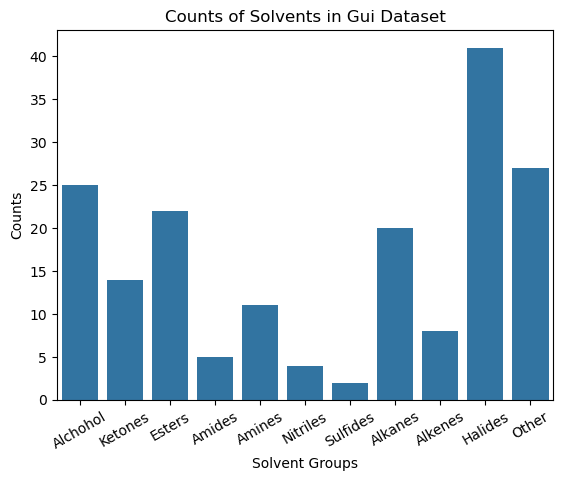

In [103]:
Solvent_plot(solvents, "Gui")

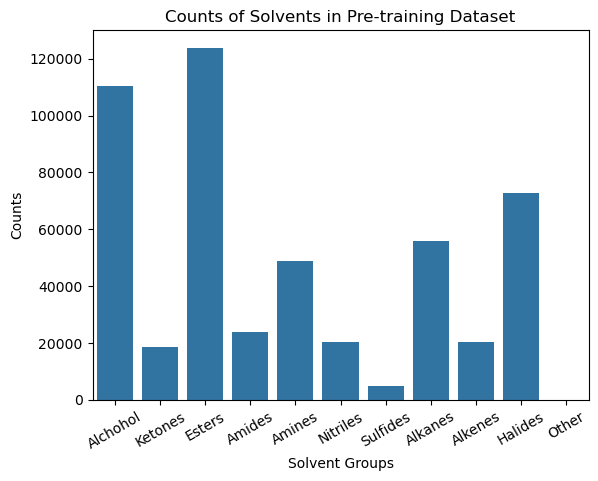

In [104]:
sols_2 = solvents_df(Chung['solvent_smiles'])
Solvent_plot(sols_2, "Pre-training")

In [37]:
# The solvents' SMILES for the pretraining and finetuning datasets
Chungsolv = Chung['solvent_smiles'].drop_duplicates(ignore_index=True)
Chungsolvfine = Chungfine['solvent_smiles'].drop_duplicates(ignore_index=True)

In [4]:
# Combined Dataframes of the pretrained and finetuned set as a control and the pretrained and Menshutkin set
Combined_solvents1 = pd.concat([Chungsolv,Men['SolventSMILES']], ignore_index=True)
Combined_solvents2 = pd.concat([Chungsolv,Chungsolvfine], ignore_index=True)

In [5]:
# See where counts of solvents exceed 1
dupes1 = Combined_solvents1.value_counts()>1
dupes2 = Combined_solvents2.value_counts()>1

In [6]:
# Number of common solvents between two datasets for each combined dataframe
print(f'common solvents between pretrain and fine: ' + str(dupes2[dupes2 == True].size))
print(f'common solvents between pretrain and Menshutkin: ' +str(dupes1[dupes1 == True].size))

common solvents between pretrain and fine: 295
common solvents between pretrain and Menshutkin: 60


In [7]:
print('THF in Chung: ' + str(Chungsolv[Chungsolv == 'C1CCOC1'].size))
print('THF in Menshutkin: ' + str(Men['SolventSMILES'][Men['SolventSMILES'] == 'C1CCOC1'].size))

THF in Chung: 1
THF in Menshutkin: 1


In [127]:
# Target values for datasets
Chung_k = Chung['ddGsolv']
Chung_kfine = Chungfine['ddGsolv']
Haas_k = Haas['lnk_experiment'].apply(lambda x: -np.log(x)*(298.15*8.314)/4184).rename('ΔGreac')
Men_k = Men['Gibbs']
comb = pd.concat([Chung_k,Haas_k], axis=1)

/var/folders/h7/hrggxsn15p58xvk395x072q80000gn/T/ipykernel_30501/3644533746.py:4: RuntimeWarning: invalid value encountered in log
  Haas_k = Haas['lnk_experiment'].apply(lambda x: -np.log(x)*(298.15*8.314)/4184).rename('ΔGreac')


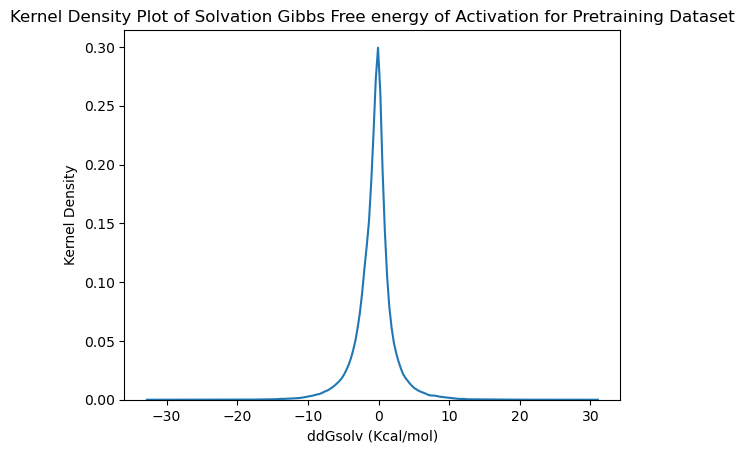

In [133]:
KDE1 = sns.kdeplot(data=Chung_k)
KDE1.set(xlabel = "ddGsolv (Kcal/mol)", 
         ylabel = "Kernel Density", 
         title = "Kernel Density Plot of Solvation Gibbs Free energy of Activation for Pretraining Dataset")
plt.show()


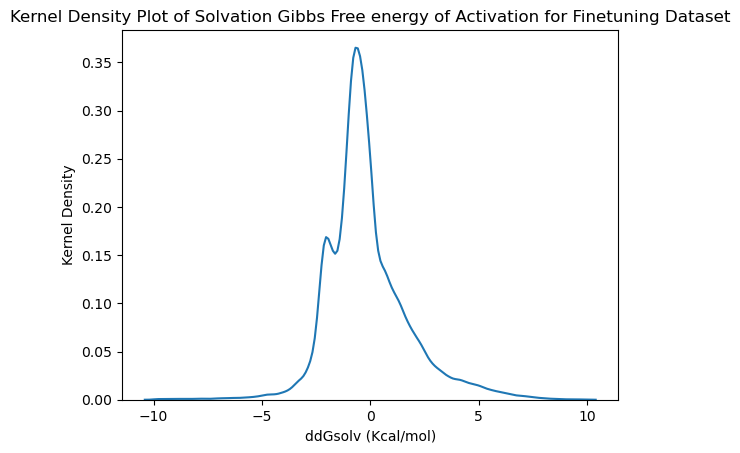

In [134]:
KDE2 = sns.kdeplot(data=Chung_kfine)
KDE2.set(xlabel = "ddGsolv (Kcal/mol)", 
         ylabel = "Kernel Density", 
         title = "Kernel Density Plot of Solvation Gibbs Free energy of Activation for Finetuning Dataset")
plt.show()

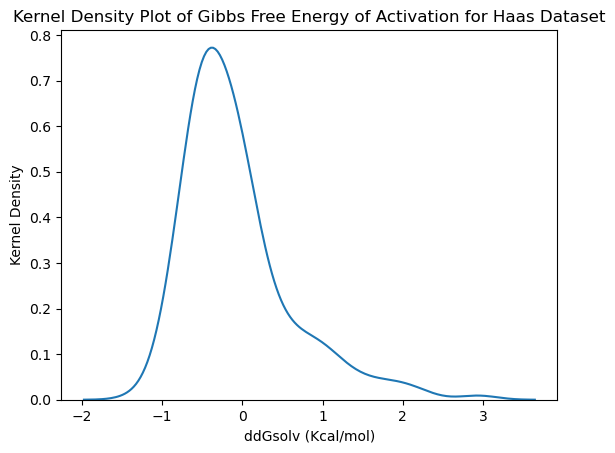

In [135]:
KDE3 = sns.kdeplot(data=Haas_k)
KDE3.set(xlabel = "ddGsolv (Kcal/mol)", 
         ylabel = "Kernel Density", 
         title = "Kernel Density Plot of Gibbs Free Energy of Activation for Haas Dataset")
plt.show()

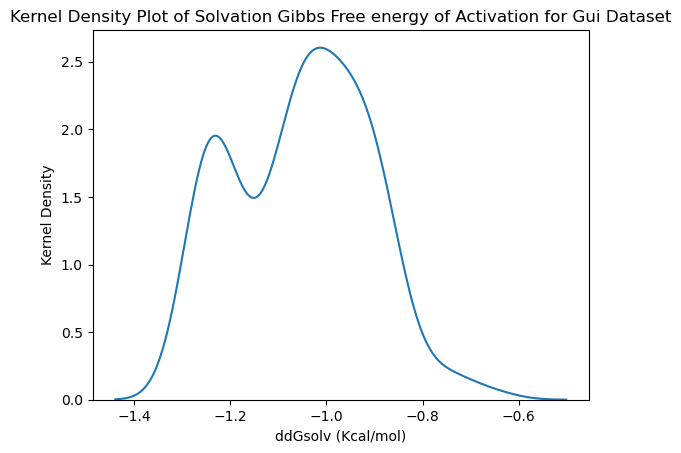

In [136]:
KDE4 = sns.kdeplot(data=-298*8.314*np.log(Men_k)/4184)
KDE4.set(xlabel = "ddGsolv (Kcal/mol)", 
         ylabel = "Kernel Density", 
         title = "Kernel Density Plot of Solvation Gibbs Free energy of Activation for Gui Dataset")
plt.show()

In [126]:
# Pyridine + Phenacyl Bromide reaction in Menshutkin reaction
reac = 'C1=CC=NC=C1.C1=CC=C(C=C1)C(=O)CBr>>C1=CC=C(C=C1)C(=O)C[N+]2=CC=CC=C2.[Br-]'
reacmol = AllChem.ReactionFromSmarts(reac, useSmiles=True)

In [13]:
# Reaction SMARTS for unique reactions in the Chung and Haas datasets
Chungprereac = Chung['rxn_smiles'].drop_duplicates(ignore_index=True).apply(lambda x:AllChem.ReactionFromSmarts(x))
Chungfinereac = Chungfine['rxn_smiles'].drop_duplicates(ignore_index=True).apply(lambda x:AllChem.ReactionFromSmarts(x))
Haasreac = Haas['ReactionSMILES'].drop_duplicates(ignore_index=True).apply(lambda x:AllChem.ReactionFromSmarts(x, useSmiles=True))

### Check for Common and Similar reactions between Chung datasets and the test datasets

In [109]:
def Common_Reactions(large_df, small_df):
    Present_Reactions_fine = np.array([])
    for value in small_df:
        reacequal = large_df.apply(lambda x:rdChemReactions.HasReactionSubstructMatch(x,value) and rdChemReactions.HasReactionSubstructMatch(value,x))
        reacequal = reacequal[reacequal == True]
        Present_Reactions_fine=np.append(Present_Reactions_fine,reacequal.size)
    print(Present_Reactions_fine.sum())
    

In [113]:
def Similar_Reactions(large_df, small_df):
    Present_Reactions_fine = np.array([])
    for value in small_df:
        reacequal = large_df.apply(lambda x:rdChemReactions.HasReactionSubstructMatch(x,value) or rdChemReactions.HasReactionSubstructMatch(value,x))
        reacequal = reacequal[reacequal == True]
        Present_Reactions_fine=np.append(Present_Reactions_fine,reacequal.size)
    print(Present_Reactions_fine.sum())


In [110]:
Common_Reactions(Chungfinereac, Haasreac)

0.0


In [111]:
#Number of Common reactions between Haas and Chung pretraining datasets
Common_Reactions(Chungprereac, Haasreac)

0.0


In [114]:
Similar_Reactions(Chungfinereac, Haasreac)

0.0


In [115]:
Similar_Reactions(Chungprereac, Haasreac)

0.0


In [16]:
# Check if Menshutkin reaction is in Chung pretraining dataset
C3 = Chungprereac.apply(lambda x:rdChemReactions.HasReactionSubstructMatch(x,reacmol) and rdChemReactions.HasReactionSubstructMatch(reacmol,x))
C3[C3 == True].size

0

In [17]:
# Check if Menshutkin reaction is in Chung finetuning dataset
C4 = Chungfinereac.apply(lambda x:rdChemReactions.HasReactionSubstructMatch(x,reacmol) and rdChemReactions.HasReactionSubstructMatch(reacmol,x))
C4[C4 == True].size

0

In [20]:
#Number of Similar reactions between Haas and Chung pretraining datasets
C3 = Chungprereac.apply(lambda x:rdChemReactions.HasReactionSubstructMatch(x,reacmol) or rdChemReactions.HasReactionSubstructMatch(reacmol,x))
C3[C3 == True].size

0

In [21]:
#Number of Similar reactions between Haas and Chung finetuning datasets
C4 = Chungfinereac.apply(lambda x:rdChemReactions.HasReactionSubstructMatch(x,reacmol) or rdChemReactions.HasReactionSubstructMatch(reacmol,x))
C4[C4 == True].size

0